In [ ]:
# Problem Statement: Design and implement a Multilayer Perceptron (MLP) for classification of the Iris or Wine 
# dataset, and evaluate its performance using accuracy and a confusion matrix.

In [1]:
!pip install -q kaggle

In [ ]:
#importing the os module and setting the KAGGLE_API_TOKEN environment variable to access Kaggle datasets
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_f9c7ca54c817498323213beac2565163"

In [ ]:
# listing the datasets available on Kaggle related to butterflies
!kaggle datasets list -s butterfly

ref                                                        title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
phucthaiv02/butterfly-image-classification                 Butterfly Image Classification                        236814249  2026-06-26 08:58:37.513000          31900        222                1  
veeralakrishna/butterfly-dataset                           Butterfly Dataset                                     476468534  2020-01-10 12:07:42.413000           5543        103            0.875  
gpiosenka/butterfly-images40-species                       Butterfly & Moths Image Classification 100 species    418471259  2023-04-21 22:53:16.223000          16365        161                1  
alessiocorrado99/ani

In [ ]:
#Downloading the butterfly image classification dataset from Kaggle
!kaggle datasets download -d phucthaiv02/butterfly-image-classification

Dataset URL: https://www.kaggle.com/datasets/phucthaiv02/butterfly-image-classification
License(s): CC0-1.0
100% 226M/226M [00:02<00:00, 88.3MB/s]



In [ ]:
#unzipping the downloaded dataset into a folder named 'butterfly_dataset'
!unzip -q butterfly-image-classification.zip -d butterfly_dataset

In [ ]:
#setting the path to the dataset and listing the files in the dataset directory
import os

dataset_path = "/content/butterfly_dataset"

os.listdir(dataset_path)

['Testing_set.csv', 'train', 'test', 'Training_set.csv']

In [ ]:
#importing pandas library to read the CSV file containing the training data
import pandas as pd

train_csv = pd.read_csv(
    "/content/butterfly_dataset/Training_set.csv"
)

train_csv.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [8]:
train_csv.shape

(6499, 2)

In [9]:
train_csv.columns

Index(['filename', 'label'], dtype='object')

In [10]:
num_classes = train_csv['label'].nunique()

print("Number of classes:", num_classes)

Number of classes: 75


In [11]:
class_counts = train_csv['label'].value_counts()

print(class_counts)

label
MOURNING CLOAK    131
SLEEPY ORANGE     107
ATALA             100
BROWN SIPROETA     99
SCARCE SWALLOW     97
                 ... 
AMERICAN SNOOT     74
GOLD BANDED        73
MALACHITE          73
CRIMSON PATCH      72
WOOD SATYR         71
Name: count, Length: 75, dtype: int64


In [12]:
print("Minimum images in a class:", class_counts.min())
print("Maximum images in a class:", class_counts.max())

Minimum images in a class: 71
Maximum images in a class: 131


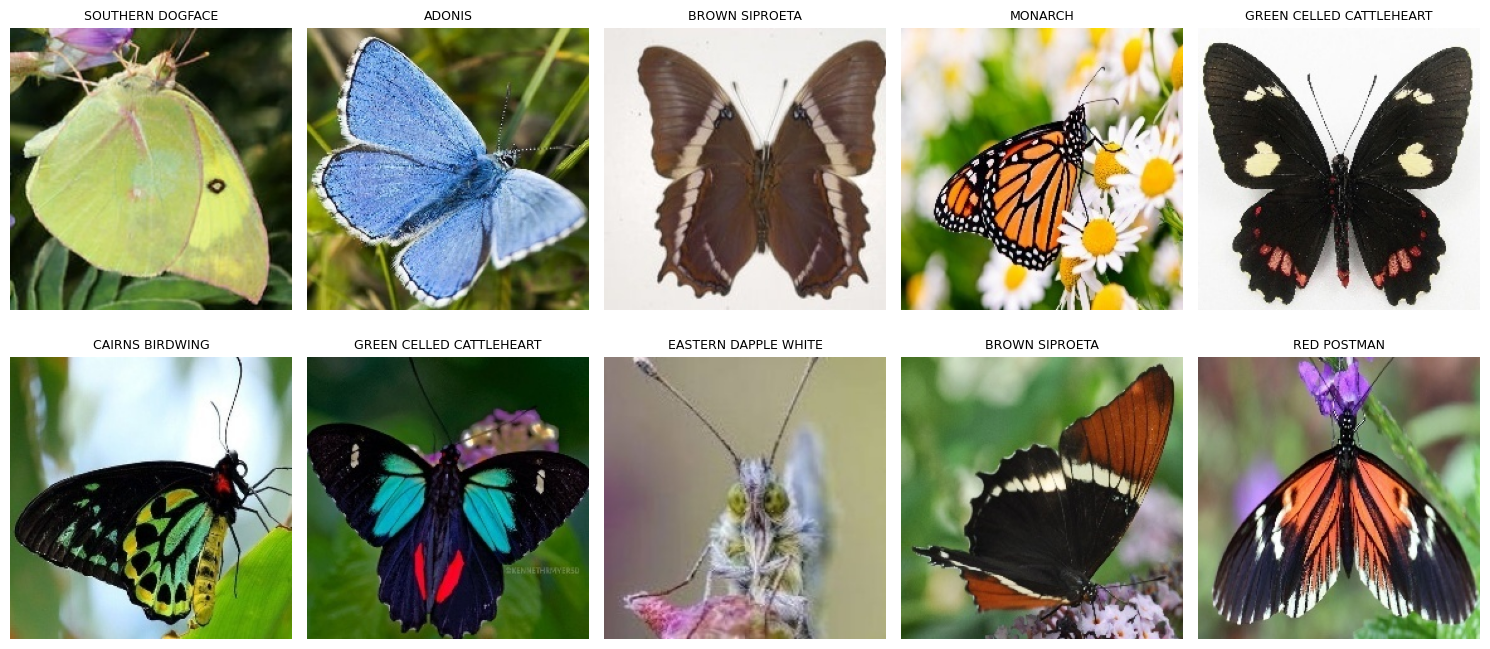

In [ ]:
#Plotting the first 10 images from the training dataset along with their corresponding labels
#PIL is used to open and manipulate images.

import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for i, ax in enumerate(axes.flat):
    row = train_csv.iloc[i]

    img_path = os.path.join(
        "/content/butterfly_dataset/train",
        row["filename"]
    )

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(row["label"], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
img = Image.open(
    "/content/butterfly_dataset/train/" + train_csv.iloc[0]["filename"]
)

print("Original image size:", img.size)
print("Image mode:", img.mode)

Original image size: (224, 224)
Image mode: RGB


In [ ]:
#to split the training dataset into training and validation sets, we can use the train_test_split function from the sklearn library. This function allows us to specify the size of the validation set and whether to stratify the split based on the labels.
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_csv,
    test_size=0.20,
    stratify=train_csv["label"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

Training images: 5199
Validation images: 1300


In [16]:
print("Training classes:", train_df["label"].nunique())
print("Validation classes:", val_df["label"].nunique())

Training classes: 75
Validation classes: 75


In [17]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [18]:
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: []


In [ ]:
#creating a mapping of class labels to integer indices and vice versa. This is useful for converting the string labels in the dataset to numerical values that can be used by machine learning models.
class_names = sorted(train_csv["label"].unique())

label_to_index = {
    label: index
    for index, label in enumerate(class_names)
}

index_to_label = {
    index: label
    for label, index in label_to_index.items()
}

print("Number of classes:", len(class_names))
print(class_names[:10])

Number of classes: 75
['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO', 'ATALA', 'BANDED ORANGE HELICONIAN', 'BANDED PEACOCK', 'BECKERS WHITE', 'BLACK HAIRSTREAK']


In [ ]:
#This ensures that the random operations performed during training and validation are consistent across different runs of the code.
train_df = train_df.copy()
val_df = val_df.copy()

train_df["label_id"] = train_df["label"].map(label_to_index)
val_df["label_id"] = val_df["label"].map(label_to_index)

In [ ]:
#setting the file paths for the training and validation images by joining the directory path with the filenames. This allows us to easily access the images during training and validation.
train_df["filepath"] = train_df["filename"].apply(
    lambda x: os.path.join(
        "/content/butterfly_dataset/train",
        x
    )
)

val_df["filepath"] = val_df["filename"].apply(
    lambda x: os.path.join(
        "/content/butterfly_dataset/train",
        x
    )
)

In [22]:
train_df.head()

,filename,label,label_id,filepath
4490,Image_4491.jpg,MANGROVE SKIPPER,40,/content/butterfly_dataset/train/Image_4491.jpg
4800,Image_4801.jpg,GREAT JAY,32,/content/butterfly_dataset/train/Image_4801.jpg
397,Image_398.jpg,SLEEPY ORANGE,64,/content/butterfly_dataset/train/Image_398.jpg
6140,Image_6141.jpg,CLEOPATRA,17,/content/butterfly_dataset/train/Image_6141.jpg
973,Image_974.jpg,PAINTED LADY,49,/content/butterfly_dataset/train/Image_974.jpg


In [47]:
import os

In [48]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
#setting the image size and batch size for training the model. 
#The image size is set to 224x224 pixels, which is a common size for image classification tasks, and the batch size is set to 32, which means that the model will process 32 images at a time during training.
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def test_load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

print("Function created successfully!")
print(test_load_image)

Function created successfully!
<function test_load_image at 0x787f82e48f40>


In [57]:
sample_path = train_df["filepath"].iloc[0]
sample_label = train_df["label_id"].iloc[0]

image, label = test_load_image(sample_path, sample_label)

print("Image shape:", image.shape)
print("Label:", label)

print("Minimum pixel value:", tf.reduce_min(image).numpy())
print("Maximum pixel value:", tf.reduce_max(image).numpy())

Image shape: (224, 224, 3)
Label: 40
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
#creating TensorFlow datasets for training and validation
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["filepath"].values,
        train_df["label_id"].values
    )
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["filepath"].values,
        val_df["label_id"].values
    )
)

In [59]:
train_ds = train_ds.map(
    test_load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    test_load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [ ]:
#Autotuning the dataset for performance by shuffling, batching, and prefetching the data. This helps to improve the training speed and efficiency of the model.
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

In [ ]:
#printing the shape of the image and label batches, as well as the minimum and maximum pixel values in the images. 
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel minimum:", tf.reduce_min(images).numpy())
print("Pixel maximum:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel minimum: 0.0
Pixel maximum: 1.0


In [ ]:
#Constructing a Convolutional Neural Network (CNN) model using the Keras Sequential API.
#The model consists of multiple convolutional and pooling layers, followed by fully connected layers for classification. 
#The final output layer uses softmax activation to produce probabilities for each of the 75 classes in the butterfly dataset.
from tensorflow.keras import layers, models

model = models.Sequential([

    # Input
    layers.Input(shape=(224, 224, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(75, activation='softmax')
])

In [63]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 75)             │         9,675 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,635 (42.64 MB)

 Trainable params: 11,178,635 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

images, labels = next(iter(train_ds))

predictions = model(images)

print("Input shape:", images.shape)
print("Prediction shape:", predictions.shape)

Input shape: (32, 224, 224, 3)
Prediction shape: (32, 75)


In [70]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [71]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 680s 4s/step - accuracy: 0.0262 - loss: 4.2709 - val_accuracy: 0.0854 - val_loss: 3.8947
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 676s 4s/step - accuracy: 0.1144 - loss: 3.6525 - val_accuracy: 0.2762 - val_loss: 3.0045
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 643s 4s/step - accuracy: 0.2447 - loss: 2.9442 - val_accuracy: 0.3992 - val_loss: 2.4501
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 639s 4s/step - accuracy: 0.3681 - loss: 2.3589 - val_accuracy: 0.4377 - val_loss: 2.1974
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 677s 4s/step - accuracy: 0.4680 - loss: 1.9126 - val_accuracy: 0.4792 - val_loss: 2.0399
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 658s 4s/step - accuracy: 0.5455 - loss: 1.5714 - val_accuracy: 0.4877 - val_loss: 1.9803
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 605s 4s/step - accuracy: 0.6136 - loss: 1.2726 - val_accuracy: 0.4992 - val_loss: 1.9355
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 661s 4s/step - accuracy: 0.6790 - loss: 1.0812 - val_accu

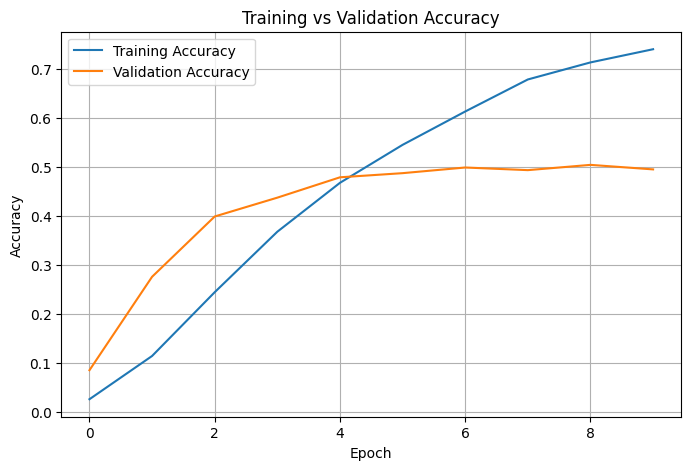

In [ ]:
#plotting the training and validation accuracy over epochs to visualize the model's performance during training. This helps to identify if the model is overfitting or underfitting.
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Evaluating the model on the validation dataset to obtain the loss and accuracy metrics. The results are printed to the console.
best_epoch = history.history["val_accuracy"].index(
    max(history.history["val_accuracy"])
) + 1

best_val_accuracy = max(history.history["val_accuracy"])

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_accuracy)

Best epoch: 9
Best validation accuracy: 0.5046153664588928


In [74]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

41/41 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.4954 - loss: 2.2051
Validation Loss: 2.2050681114196777
Validation Accuracy: 0.4953846037387848


In [ ]:
#predicting the labels for the validation dataset and storing the true labels and predicted labels in separate lists. The predictions are obtained by passing the images through the trained model and taking the argmax of the output probabilities to get the predicted class indices.
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of true labels:", len(y_true))
print("Number of predictions:", len(y_pred))

Number of true labels: 1300
Number of predictions: 1300


In [76]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

                           precision    recall  f1-score   support

                   ADONIS       0.83      0.83      0.83        18
AFRICAN GIANT SWALLOWTAIL       0.88      0.47      0.61        15
           AMERICAN SNOOT       0.18      0.13      0.15        15
                    AN 88       1.00      0.88      0.94        17
                  APPOLLO       0.34      0.78      0.47        18
                    ATALA       0.62      0.80      0.70        20
 BANDED ORANGE HELICONIAN       0.54      0.70      0.61        20
           BANDED PEACOCK       0.53      0.53      0.53        17
            BECKERS WHITE       0.15      0.19      0.17        16
         BLACK HAIRSTREAK       1.00      0.41      0.58        17
              BLUE MORPHO       0.83      0.33      0.48        15
        BLUE SPOTTED CROW       0.33      0.47      0.39        17
           BROWN SIPROETA       0.48      0.50      0.49        20
            CABBAGE WHITE       0.48      0.61      0.54     

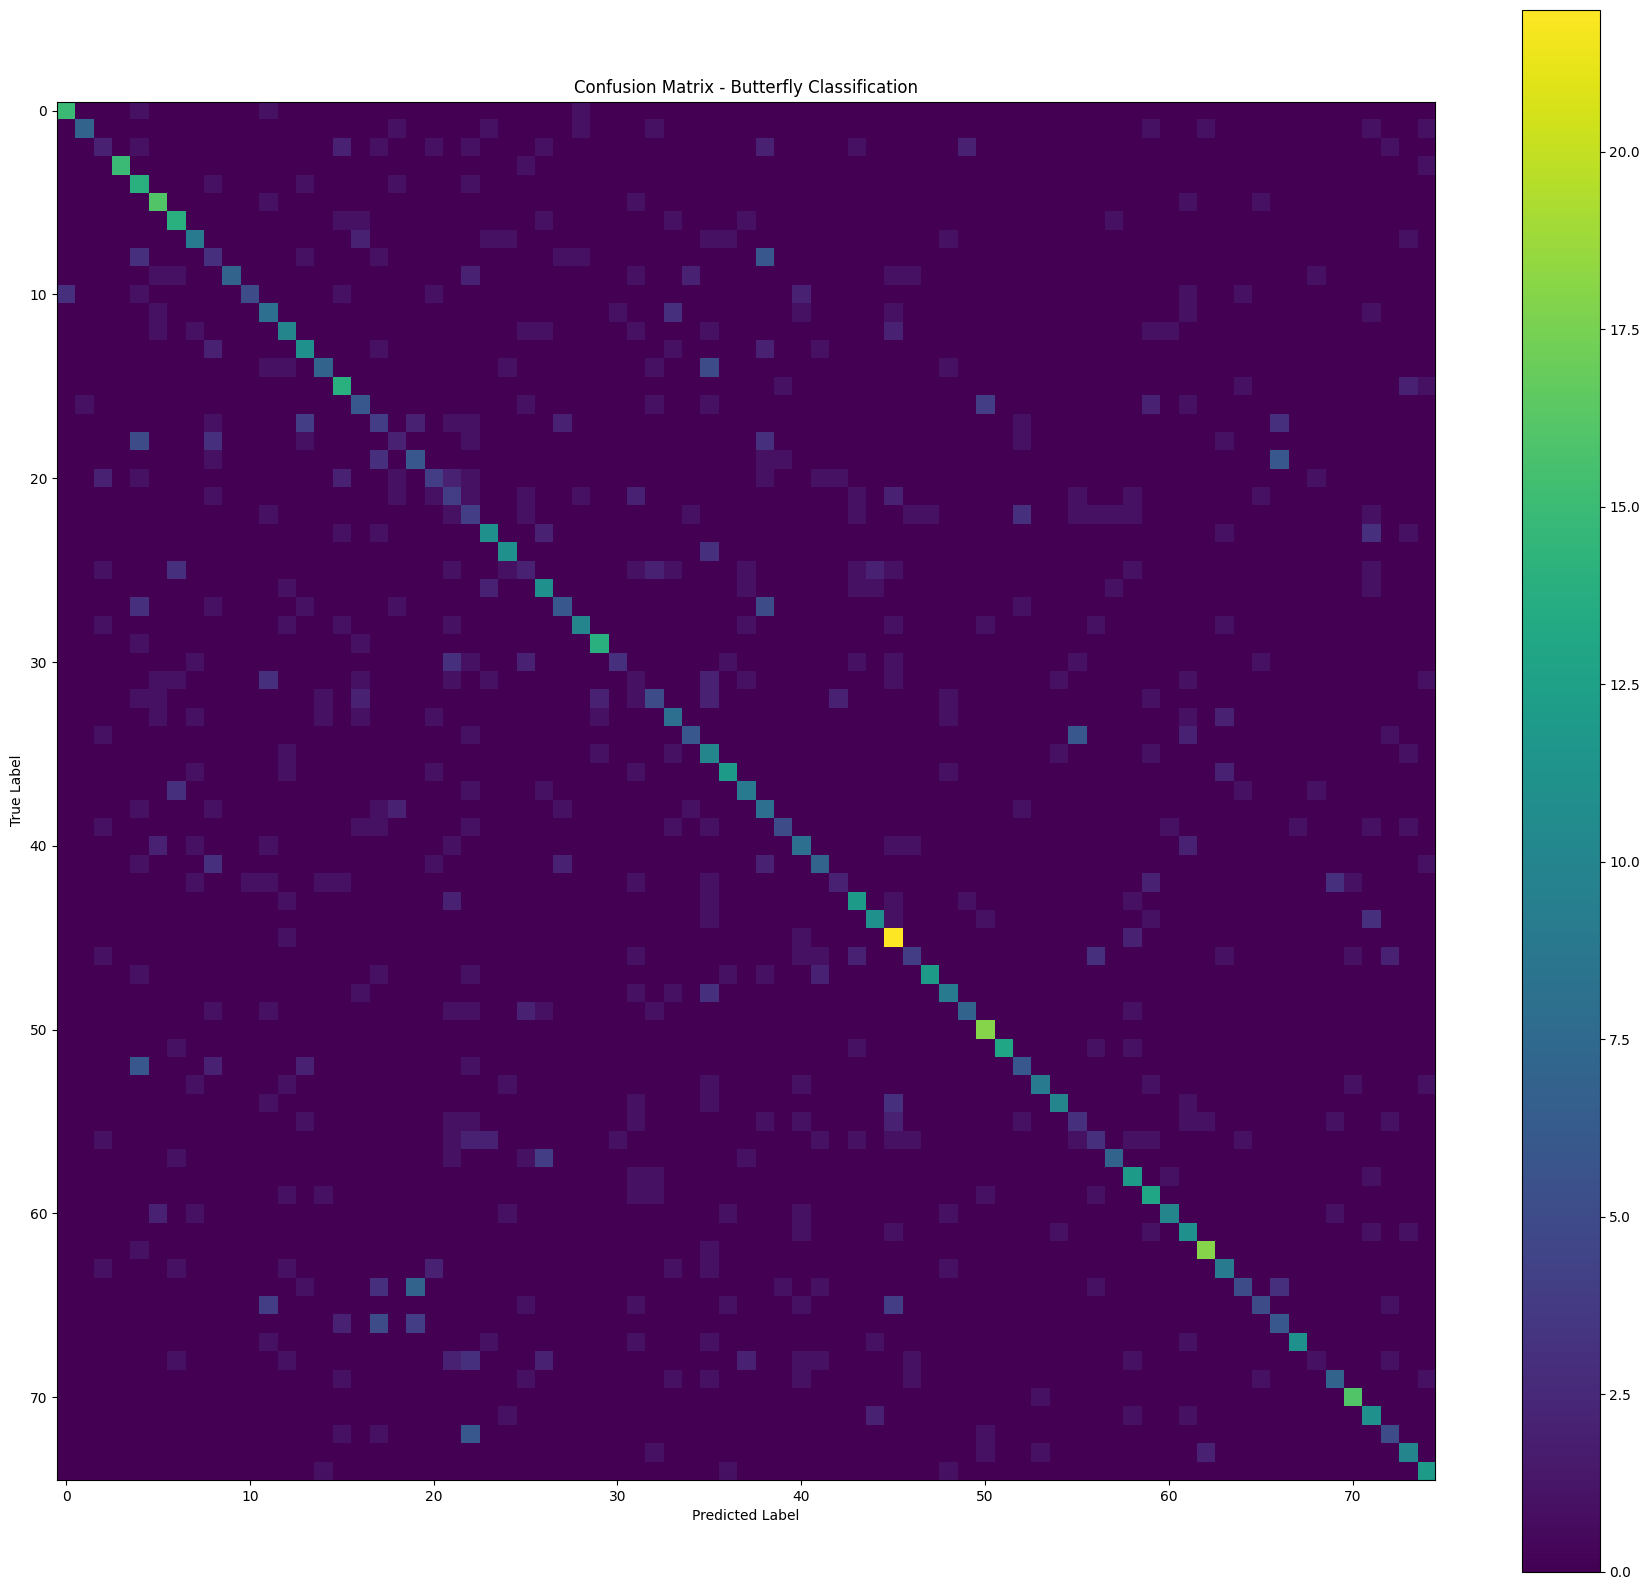

In [ ]:
#Creating a confusion matrix to visualize the performance of the model in terms of true positive, true negative, false positive, and false negative predictions for each class. The confusion matrix is displayed as a heatmap using Matplotlib.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))

plt.imshow(cm, interpolation="nearest")

plt.title("Confusion Matrix - Butterfly Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.tight_layout()
plt.show()